In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.classification import setup, compare_models,evaluate_model, plot_model, create_model, tune_model, finalize_model, predict_model, save_model
import optuna


# Innits


In [19]:
b = pd.read_csv('./data/joint/23-24/merged_player_data.csv')
# b[b['event']]
b['event'].max()

38

In [20]:
gw=35
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv') #.dropna()

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_test = data_23_24[data_23_24['event'] > gw]

# data = pd.concat([data_22_23, data_23_24, data_24_25_])


data_36 = data_test[data_test['event'] == 36]
data_37 = data_test[data_test['event'] == 37]
data_38 = data_test[data_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [21]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


In [22]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


clean_sheets
0    413
1    111
Name: count, dtype: int64


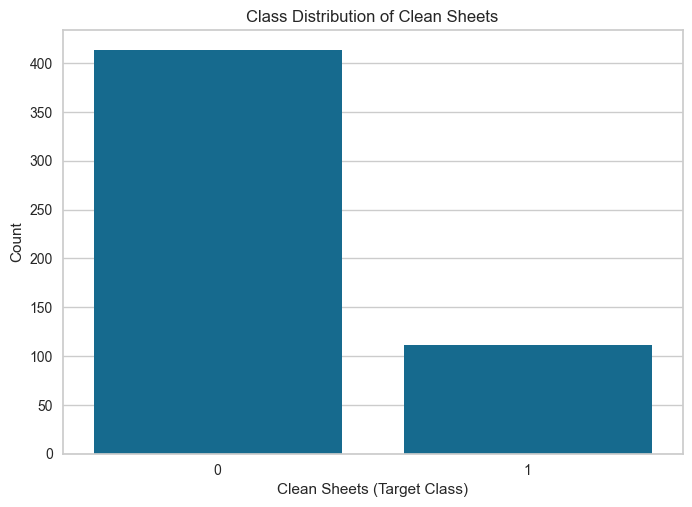

In [23]:
g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[cs_features]
g_cs_data_tar = g_cs_data_tar[cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [24]:
g_cs_base_model = setup(data=g_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        # remove_multicollinearity=True,
                        normalize=True,
                        feature_selection=True,
                        # polynomial_features=True,
                        session_id=123)

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(524, 73)"
4,Transformed data shape,"(710, 15)"
5,Transformed train set shape,"(552, 15)"
6,Transformed test set shape,"(158, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [25]:
best_base_g_cs = g_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5793,0.5663,0.5232,0.2531,0.3375,0.0794,0.0967,0.5790
ridge,Ridge Classifier,0.5793,0.5625,0.5232,0.2531,0.3375,0.0794,0.0967,0.3800
svm,SVM - Linear Kernel,0.5161,0.5624,0.5625,0.2284,0.3220,0.0372,0.0534,0.3830
lr,Logistic Regression,0.5847,0.5594,0.5232,0.2557,0.3402,0.0845,0.1023,2.2880
ada,Ada Boost Classifier,0.6532,0.5283,0.3214,0.2478,0.2732,0.0552,0.0571,0.4430
rf,Random Forest Classifier,0.6994,0.5132,0.1464,0.1628,0.1494,-0.0142,-0.0211,0.6610
lightgbm,Light Gradient Boosting Machine,0.7327,0.5082,0.2482,0.4505,0.2745,0.1262,0.1558,0.6190
et,Extra Trees Classifier,0.7323,0.5056,0.1446,0.2244,0.1641,0.0368,0.0378,0.4200
dt,Decision Tree Classifier,0.6063,0.5050,0.3304,0.2209,0.2618,0.0112,0.0096,0.5970
xgboost,Extreme Gradient Boosting,0.7161,0.5038,0.2071,0.2783,0.2235,0.0629,0.0670,0.2850


In [26]:
evaluate_model(best_base_g_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [27]:
tune_model_gk_cs = tune_model(best_base_g_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5405,0.5388,0.3750,0.2000,0.2609,-0.0295,-0.0325
1,0.6486,0.7672,0.7500,0.3529,0.4800,0.2634,0.3062
2,0.4595,0.4871,0.1250,0.0714,0.0909,-0.2542,-0.2744
3,0.5676,0.5647,0.5000,0.2500,0.3333,0.0633,0.0716
4,0.6486,0.6897,0.6250,0.3333,0.4348,0.2128,0.2349
5,0.6216,0.6422,0.6250,0.3125,0.4167,0.1804,0.2042
6,0.5000,0.3744,0.1429,0.0769,0.1000,-0.2045,-0.2232
7,0.7500,0.7635,0.8571,0.4286,0.5714,0.4214,0.4719
8,0.5833,0.4866,0.5000,0.2667,0.3478,0.0816,0.0904


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [28]:
evaluate_model(tune_model_gk_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [29]:
final_best_base_g_cs = finalize_model(tune_model_gk_cs)
save_model(final_best_base_g_cs, './models/gk_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          reg_alpha=0.

## DEF


clean_sheets
0    1618
1     383
Name: count, dtype: int64


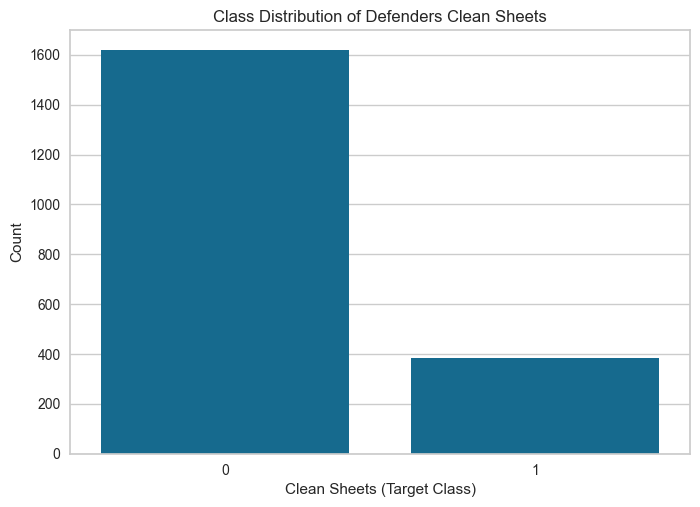

In [30]:
def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[cs_features]
def_cs_data_tar = def_cs_data_tar[cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Defenders Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [31]:
def_cs_base_model = setup(data=def_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1081, number of negative: 1081
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002350 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14010
[LightGBM] [Info] Number of data points in the train set: 2162, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(2001, 73)"
4,Transformed data shape,"(2763, 15)"
5,Transformed train set shape,"(2162, 15)"
6,Transformed test set shape,"(601, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [32]:
best_base_def_cs = def_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8493,0.8411,0.4340,0.6748,0.5193,0.4364,0.4561,1.5980
rf,Random Forest Classifier,0.8343,0.8069,0.3890,0.6079,0.4674,0.3766,0.3931,1.6390
lightgbm,Light Gradient Boosting Machine,0.8371,0.8017,0.3959,0.6264,0.4808,0.3905,0.4073,1.7490
xgboost,Extreme Gradient Boosting,0.8357,0.7959,0.4225,0.6050,0.4921,0.3989,0.4108,1.2000
gbc,Gradient Boosting Classifier,0.8000,0.7419,0.2803,0.4663,0.3444,0.2368,0.2498,1.7940
knn,K Neighbors Classifier,0.6207,0.7206,0.7278,0.3015,0.4253,0.2115,0.2563,1.1450
qda,Quadratic Discriminant Analysis,0.6657,0.6658,0.4855,0.2831,0.3547,0.1511,0.1632,1.0860
ada,Ada Boost Classifier,0.7400,0.6623,0.3620,0.3351,0.3442,0.1844,0.1860,1.1140
ridge,Ridge Classifier,0.6121,0.6560,0.6083,0.2727,0.3751,0.1513,0.1770,1.2200
lr,Logistic Regression,0.6107,0.6553,0.6083,0.2716,0.3742,0.1496,0.1754,1.5660


In [33]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [34]:
tune_model_def_cs = tune_model(best_base_def_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6857,0.7571,0.4815,0.3023,0.3714,0.1763,0.1847
1,0.6643,0.6853,0.5556,0.3000,0.3896,0.1856,0.2024
2,0.7429,0.7289,0.4444,0.3636,0.4000,0.2384,0.2404
3,0.6643,0.6637,0.5926,0.3077,0.4051,0.2026,0.2237
4,0.7000,0.7348,0.5926,0.3404,0.4324,0.2483,0.2659
5,0.7571,0.7775,0.5926,0.4103,0.4848,0.3328,0.3424
6,0.6643,0.6296,0.3704,0.2500,0.2985,0.0886,0.0916
7,0.6286,0.6640,0.5556,0.2727,0.3659,0.1445,0.1628
8,0.6286,0.6856,0.6538,0.2833,0.3953,0.1839,0.2174


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [35]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [36]:
final_best_base_def_cs = finalize_model(best_base_def_cs)
save_model(final_best_base_def_cs, './models/def_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

## MID


clean_sheets
0    1653
1     423
Name: count, dtype: int64


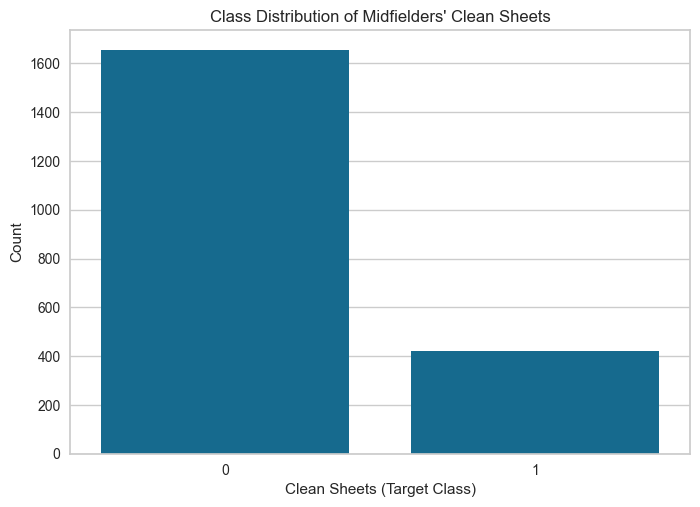

In [37]:
mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[cs_features]
mid_cs_data_tar = mid_cs_data_tar[cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Midfielders\' Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [38]:
mid_cs_base_model = setup(data=mid_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1106, number of negative: 1106
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14367
[LightGBM] [Info] Number of data points in the train set: 2212, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(2076, 73)"
4,Transformed data shape,"(2835, 15)"
5,Transformed train set shape,"(2212, 15)"
6,Transformed test set shape,"(623, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [39]:
best_base_mid_cs = mid_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)


In [40]:
evaluate_model(best_base_mid_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [41]:
tune_model_mid_cs = tune_model(best_base_mid_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5822,0.5948,0.5333,0.2540,0.3441,0.0910,0.1046
1,0.6575,0.6158,0.3667,0.2619,0.3056,0.0866,0.0887
2,0.6644,0.6351,0.3667,0.2683,0.3099,0.0951,0.0971
3,0.6276,0.6584,0.4828,0.2642,0.3415,0.1118,0.1217
4,0.6966,0.5684,0.2414,0.2414,0.2414,0.0517,0.0517
5,0.6207,0.6709,0.5862,0.2833,0.3820,0.1538,0.1750
6,0.5103,0.6032,0.6552,0.2375,0.3486,0.0779,0.1040
7,0.7241,0.7116,0.4000,0.3529,0.3750,0.1989,0.1995
8,0.5862,0.6009,0.5667,0.2656,0.3617,0.1113,0.1289


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [42]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [43]:
final_best_base_mid_cs = finalize_model(best_base_mid_cs)
save_model(final_best_base_mid_cs, './models/mid_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

# Yellow Cards


In [44]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


yellow_cards
0    485
1     39
Name: count, dtype: int64


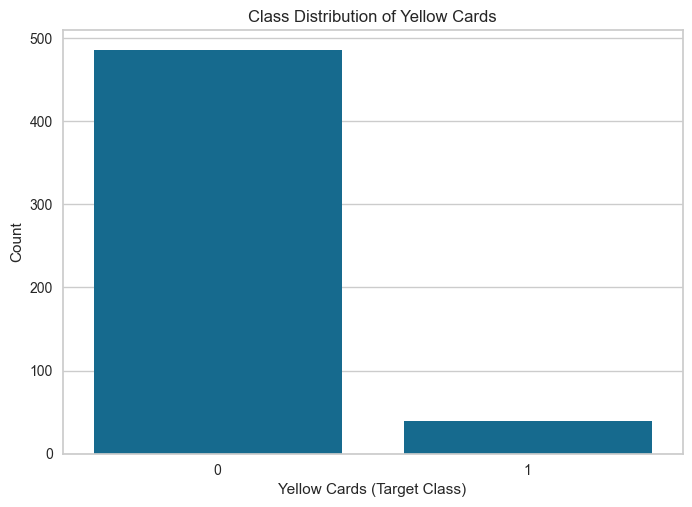

In [45]:
g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[y_features]
g_y_data_tar = g_y_data_tar[y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [46]:
g_y_base_model = setup(data=g_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 322, number of negative: 322
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7838
[LightGBM] [Info] Number of data points in the train set: 644, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(524, 75)"
4,Transformed data shape,"(802, 15)"
5,Transformed train set shape,"(644, 15)"
6,Transformed test set shape,"(158, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [47]:
best_base_g_y = g_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.8744,0.5900,0.1167,0.0976,0.0956,0.0377,0.0415,0.9160
svm,SVM - Linear Kernel,0.5325,0.5719,0.6000,0.0925,0.1551,0.0344,0.0705,0.6140
ridge,Ridge Classifier,0.6148,0.5410,0.4500,0.0883,0.1470,0.0280,0.0404,0.7250
lda,Linear Discriminant Analysis,0.6148,0.5380,0.4500,0.0883,0.1470,0.0280,0.0404,0.6860
lr,Logistic Regression,0.6230,0.5351,0.4667,0.0874,0.1464,0.0283,0.0481,0.5830
rf,Random Forest Classifier,0.8880,0.5035,0.0000,0.0000,0.0000,-0.0481,-0.0524,0.7960
dummy,Dummy Classifier,0.9264,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6400
nb,Naive Bayes,0.6010,0.4956,0.2000,0.0438,0.0708,-0.0565,-0.0875,0.6570
dt,Decision Tree Classifier,0.8146,0.4851,0.1000,0.1333,0.0944,0.0067,0.0091,0.5650
gbc,Gradient Boosting Classifier,0.8881,0.4760,0.0500,0.0500,0.0500,0.0023,-0.0002,0.7870


In [48]:
evaluate_model(best_base_g_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [49]:
tune_model_gk_y = tune_model(best_base_g_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6757,0.9118,1.0000,0.2000,0.3333,0.2292,0.3597
1,0.5946,0.5490,0.6667,0.1250,0.2105,0.0857,0.1404
2,0.7027,0.3725,0.0000,0.0000,0.0000,-0.1337,-0.1560
3,0.6216,0.3235,0.3333,0.0769,0.1250,-0.0078,-0.0112
4,0.4865,0.5784,0.3333,0.0556,0.0952,-0.0508,-0.0910
5,0.7027,0.5490,0.3333,0.1000,0.1538,0.0333,0.0422
6,0.6111,0.4118,0.0000,0.0000,0.0000,-0.1053,-0.1715
7,0.6389,0.7059,0.5000,0.0769,0.1333,0.0410,0.0701
8,0.5833,0.4706,0.0000,0.0000,0.0000,-0.1066,-0.1823


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [50]:
final_best_base_g_y = finalize_model(best_base_g_y)
save_model(final_best_base_g_y, './models/gk_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          n_jobs=None,

## DEF


yellow_cards
0    1680
1     321
Name: count, dtype: int64


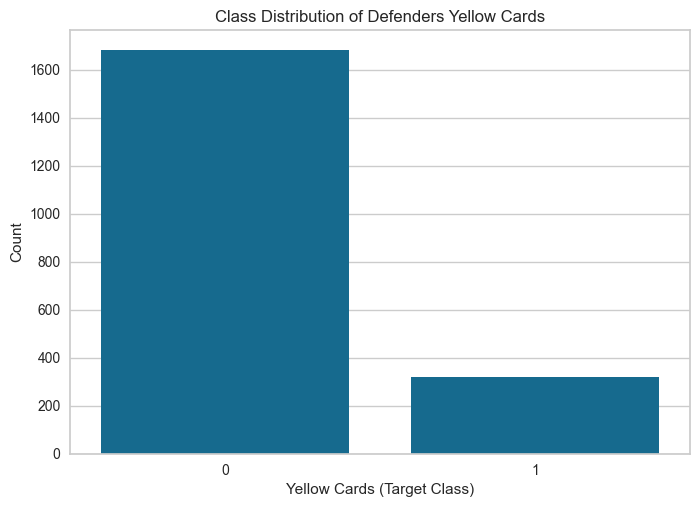

In [51]:
def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[y_features]
def_y_data_tar = def_y_data_tar[y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Defenders Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [52]:
def_y_base_model = setup(data=def_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1118, number of negative: 1118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14628
[LightGBM] [Info] Number of data points in the train set: 2236, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(2001, 75)"
4,Transformed data shape,"(2837, 15)"
5,Transformed train set shape,"(2236, 15)"
6,Transformed test set shape,"(601, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [53]:
best_base_def_y = def_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8057,0.5769,0.0709,0.2536,0.1070,0.0267,0.0410,2.2040
et,Extra Trees Classifier,0.7957,0.5644,0.0931,0.2123,0.1280,0.0308,0.0355,1.2550
gbc,Gradient Boosting Classifier,0.7993,0.5628,0.0704,0.2057,0.1027,0.0148,0.0217,2.0620
ada,Ada Boost Classifier,0.7343,0.5626,0.2170,0.2067,0.2091,0.0520,0.0521,1.7330
xgboost,Extreme Gradient Boosting,0.8043,0.5560,0.0970,0.2824,0.1402,0.0521,0.0676,1.7700
knn,K Neighbors Classifier,0.5257,0.5506,0.5737,0.1869,0.2815,0.0510,0.0668,1.2810
lr,Logistic Regression,0.5371,0.5498,0.4923,0.1719,0.2546,0.0218,0.0281,1.5660
lda,Linear Discriminant Analysis,0.5350,0.5498,0.5010,0.1729,0.2568,0.0240,0.0314,1.2180
ridge,Ridge Classifier,0.5350,0.5489,0.5010,0.1729,0.2568,0.0240,0.0314,1.1400
rf,Random Forest Classifier,0.7943,0.5436,0.0662,0.2186,0.0964,0.0045,0.0155,1.5810


In [54]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

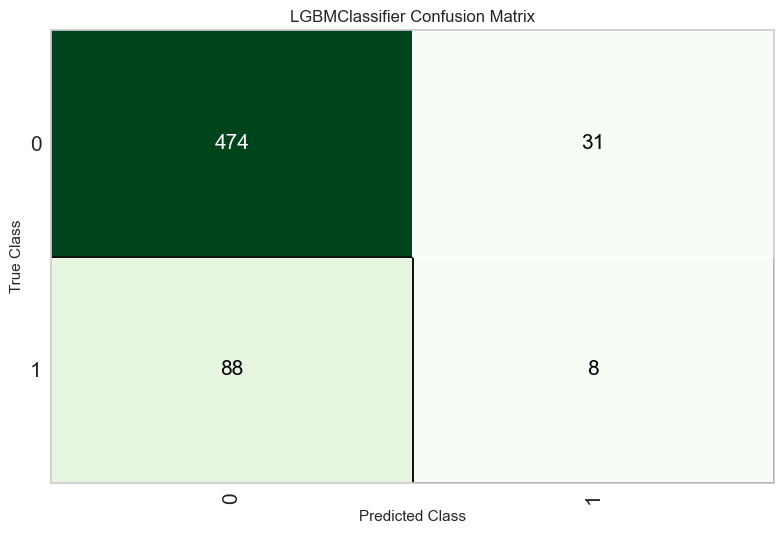

In [55]:
plot_model(best_base_def_y, plot='confusion_matrix')

### Tuned Model


In [56]:
tune_model_def_y = tune_model(best_base_def_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.3871,0.0455,0.1250,0.0667,-0.0187,-0.0217
1,0.8357,0.5439,0.0455,0.3333,0.0800,0.0439,0.0716
2,0.8357,0.5859,0.1364,0.4286,0.2069,0.1418,0.1711
3,0.7643,0.5266,0.0909,0.1333,0.1081,-0.0221,-0.0227
4,0.8143,0.4507,0.0455,0.1667,0.0714,0.0044,0.0055
5,0.8429,0.6403,0.2609,0.5455,0.3529,0.2760,0.3004
6,0.8071,0.6934,0.1739,0.3333,0.2286,0.1306,0.1397
7,0.7857,0.5295,0.0435,0.1111,0.0625,-0.0330,-0.0376
8,0.7786,0.5552,0.0870,0.1667,0.1143,0.0018,0.0020


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [57]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [58]:
final_best_base_def_y = finalize_model(best_base_def_y)
save_model(final_best_base_def_y, './models/def_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                            

## MID


yellow_cards
0    1718
1     358
Name: count, dtype: int64


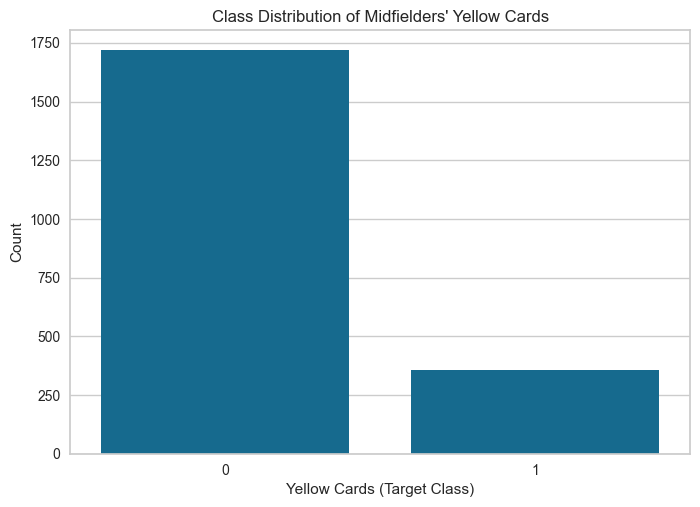

In [59]:
mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[y_features]
mid_y_data_tar = mid_y_data_tar[y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Midfielders\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [60]:
mid_y_base_model = setup(data=mid_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1142, number of negative: 1142
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14872
[LightGBM] [Info] Number of data points in the train set: 2284, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(2076, 75)"
4,Transformed data shape,"(2907, 15)"
5,Transformed train set shape,"(2284, 15)"
6,Transformed test set shape,"(623, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [61]:
best_base_mid_y = mid_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.5816,0.6080,0.5655,0.2233,0.3195,0.0950,0.1153,2.8320
lr,Logistic Regression,0.5836,0.6076,0.5615,0.2231,0.3187,0.0947,0.1148,2.1430
ada,Ada Boost Classifier,0.7440,0.6073,0.2312,0.2507,0.2383,0.0859,0.0867,2.3720
lda,Linear Discriminant Analysis,0.5844,0.6054,0.5697,0.2253,0.3223,0.0990,0.1203,1.1460
et,Extra Trees Classifier,0.7887,0.6013,0.1474,0.2992,0.1928,0.0871,0.0967,2.0830
gbc,Gradient Boosting Classifier,0.7949,0.5999,0.1352,0.3181,0.1832,0.0878,0.1014,2.5130
rf,Random Forest Classifier,0.7880,0.5977,0.1274,0.2725,0.1697,0.0672,0.0751,3.0460
lightgbm,Light Gradient Boosting Machine,0.7908,0.5962,0.1192,0.2823,0.1634,0.0651,0.0757,2.1490
nb,Naive Bayes,0.4454,0.5922,0.7255,0.1992,0.3122,0.0562,0.0873,0.8510
svm,SVM - Linear Kernel,0.5183,0.5846,0.6451,0.2101,0.3151,0.0755,0.1056,1.8030


In [62]:
evaluate_model(best_base_mid_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [63]:
tune_model_mid_y = tune_model(best_base_mid_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5068,0.6067,0.6154,0.2051,0.3077,0.0554,0.0757
1,0.6096,0.6522,0.6800,0.2576,0.3736,0.1666,0.2082
2,0.5890,0.6317,0.7200,0.2535,0.3750,0.1630,0.2125
3,0.5103,0.4993,0.4400,0.1618,0.2366,-0.0208,-0.0265
4,0.5931,0.5963,0.5200,0.2167,0.3059,0.0826,0.0984
5,0.6483,0.6647,0.6000,0.2679,0.3704,0.1733,0.2004
6,0.6276,0.6243,0.5600,0.2456,0.3415,0.1338,0.1560
7,0.5241,0.5343,0.4800,0.1765,0.2581,0.0079,0.0101
8,0.6414,0.7127,0.6000,0.2632,0.3659,0.1659,0.1933


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [64]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [65]:
final_best_base_mid_y = finalize_model(tune_model_mid_y)
save_model(final_best_base_mid_y, './models/mid_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          reg_alpha=0.

## FWD


yellow_cards
0    454
1     67
Name: count, dtype: int64


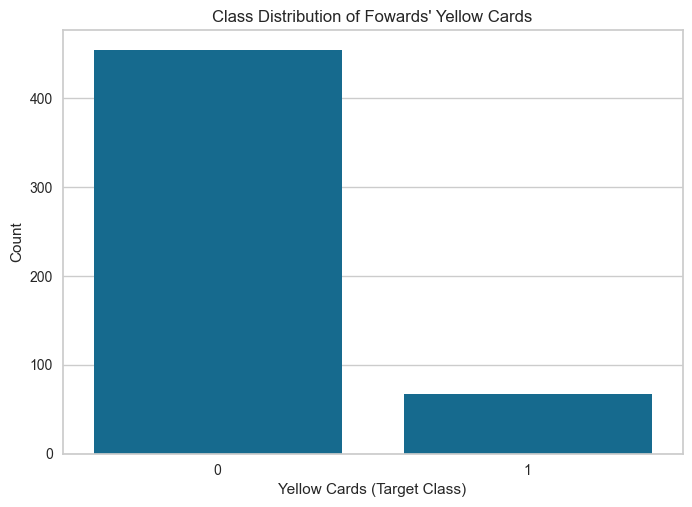

In [66]:
fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[y_features]
fwd_y_data_tar = fwd_y_data_tar[y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Fowards\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [67]:
fwd_y_base_model = setup(data=fwd_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 303, number of negative: 303
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9341
[LightGBM] [Info] Number of data points in the train set: 606, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(521, 75)"
4,Transformed data shape,"(763, 15)"
5,Transformed train set shape,"(606, 15)"
6,Transformed test set shape,"(157, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [68]:
best_base_fwd_y = fwd_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8215,0.5169,0.0250,0.0250,0.0250,-0.0446,-0.0481,0.9910
rf,Random Forest Classifier,0.8105,0.5143,0.0650,0.1833,0.0905,-0.0054,0.0068,0.8520
dummy,Dummy Classifier,0.8709,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5060
gbc,Gradient Boosting Classifier,0.7719,0.4785,0.0650,0.0843,0.0668,-0.0543,-0.0545,0.9540
lightgbm,Light Gradient Boosting Machine,0.7884,0.4773,0.0450,0.0500,0.0450,-0.0637,-0.0676,0.6190
qda,Quadratic Discriminant Analysis,0.7144,0.4676,0.1350,0.0811,0.0980,-0.0615,-0.0607,0.5610
lda,Linear Discriminant Analysis,0.5605,0.4662,0.3650,0.1132,0.1721,-0.0284,-0.0329,0.7110
ridge,Ridge Classifier,0.5605,0.4655,0.3650,0.1132,0.1721,-0.0284,-0.0329,0.9220
svm,SVM - Linear Kernel,0.5551,0.4653,0.4250,0.1146,0.1784,-0.0187,-0.0065,0.9170
xgboost,Extreme Gradient Boosting,0.7938,0.4649,0.0200,0.0250,0.0222,-0.0757,-0.0843,0.4750


In [69]:
evaluate_model(best_base_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [70]:
tune_model_fwd_y = tune_model(best_base_fwd_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7027,0.8281,1.0000,0.3125,0.4762,0.3404,0.4529
1,0.8649,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.5946,0.5969,0.6000,0.1875,0.2857,0.1005,0.1337
3,0.1351,0.5000,1.0000,0.1351,0.2381,0.0000,0.0000
4,0.6944,0.5000,0.2500,0.1111,0.1538,0.0000,0.0000
5,0.1111,0.5000,1.0000,0.1111,0.2000,0.0000,0.0000
6,0.6111,0.5625,0.5000,0.1429,0.2222,0.0597,0.0806
7,0.5833,0.5065,0.4000,0.1429,0.2105,0.0074,0.0092
8,0.6944,0.6548,0.6000,0.2500,0.3529,0.1951,0.2272


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [71]:
evaluate_model(tune_model_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [72]:
final_best_base_fwd_y = finalize_model(tune_model_fwd_y)
save_model(final_best_base_fwd_y, './models/fwd_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=True, ccp_alpha=0.0,
                                